# Seasonality and trend

In [3]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme(palette="Set2")

In [ ]:
def random_walk(obs=100, m=0, stdev=0.5, d=1):
    """
    :param: obs: number of observations
    :param: m: mean
    :param: stdev: standard deviation
    :param: d: number of dimensions
    """
    return np.cumsum(np.random.normal(m, stdev, (obs, d)))

def white_noise(obs=100, m=0, stdev=0.5, d=1):
    return np.random.normal(m, stdev, (obs, d)).flatten()

def red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.7):
    white = white_noise(obs, m, stdev, d)
    red = np.zeros_like(white)
    for i in range(1, len(white)):
        red[i] = corr * red[i-1] + white[i]
    return red

def linear_trend(obs=100, d=1, y_start=0, y_stop=10):
    return np.linspace(start=y_start, stop=y_stop, num=obs).reshape(-1, 1).flatten()

def exp_trend(nobs=100, a=0.001, b=1.01):
    t = np.arange(nobs).reshape(-1, 1).flatten()
    return a * b**t

def log_trend(nobs=100, a=1, b=2):
    t = np.arange(nobs)
    k = (b - 1) / np.log(nobs)
    return a * (1 + k * np.log(1 + t))

def seasonality(obs=100, d=1, period=7, y_max=2):
    """
    :param: obs: number of observations
    :param: d: number of dimensions
    :param: period: period of the seasonal component
    :param: y_max: maximum value of the seasonal component
    """
    t = np.arange(obs)
    return y_max * np.sin(2 * np.pi * t / period).reshape(-1, d).flatten()

def structural_break(t, break_point=50, size=2):
    """:param: t: time points
    :param: break_point: index where the structural break occurs
    """
    t[break_point:] += size 
    return t

def segmented_trend(obs=100, y_start=0, y_stop=10, d=1, 
                    segment_start=0.5, segment_end=0.7, segment_y_start=1, segment_y_stop=5):
    segment_start = int(segment_start*obs)
    segment_end = int(segment_end*obs)
    t1 = linear_trend(segment_start, d, y_start=y_start, y_stop=segment_y_start)
    t2 = linear_trend(segment_end - segment_start, d, y_start=segment_y_start, y_stop=segment_y_stop)
    t3 = linear_trend(obs - segment_end, d, y_start=segment_y_stop, y_stop=y_stop)
    t = np.concatenate([t1, t2, t3])
    return t

def anomalies(t, anomaly_point=70, size=2):
    t[anomaly_point] += size  
    return t

## Trend

<Axes: >

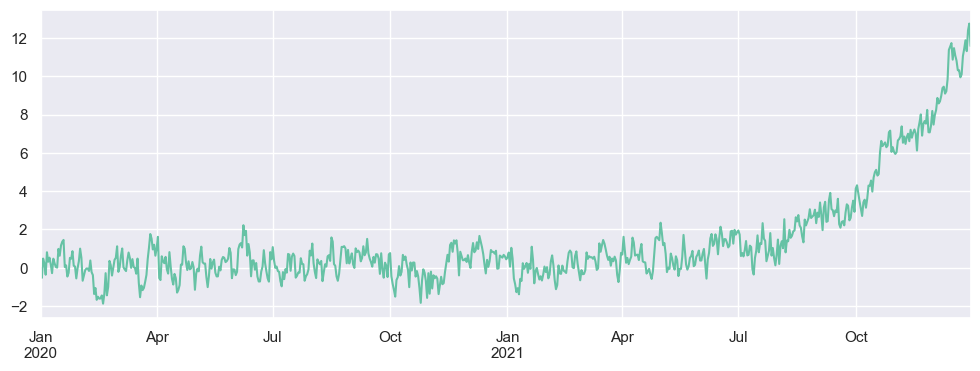

In [222]:
nobs = 365 * 2

rn = red_noise(nobs)
et = exp_trend(nobs, b=1.013)
ts = rn + et

dates = pd.date_range(start="01-01-2020", periods=nobs, freq="D") 
df = pd.DataFrame(data=ts, index=dates)
df.plot(figsize=(12, 4), legend=False)

<Axes: >

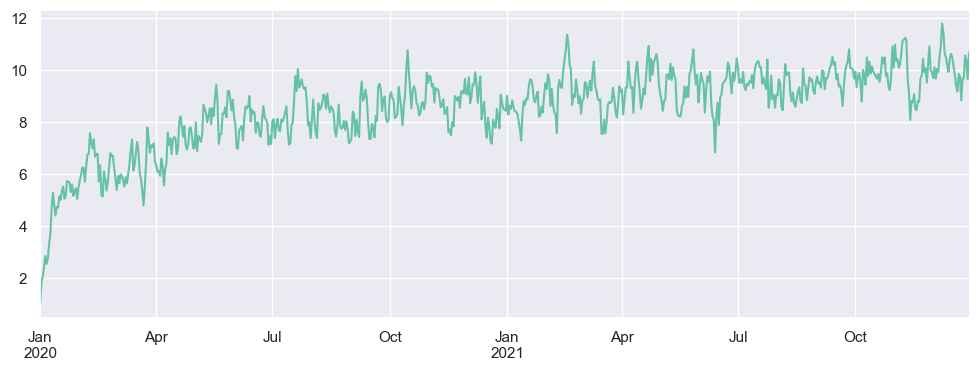

In [234]:
rn = red_noise(nobs)
lt = log_trend(nobs, a=1, b=10)
ts = rn + lt

dates = pd.date_range(start="01-01-2020", periods=nobs, freq="D") 
df = pd.DataFrame(data=ts, index=dates)
df.plot(figsize=(12, 4), legend=False)

In [ ]:
import yfinance as yf

# Define tickers
tickers = ["AAPL", "JNJ", "KO", "JPM", "INTC", "META"]

# Download data
data = yf.download(
    tickers,
    start="2010-01-01",
    end="2025-01-01",
    interval="1d" # 1d
)

# Extract only the Close prices
close_prices = data["Close"]

[*********************100%***********************]  6 of 6 completed


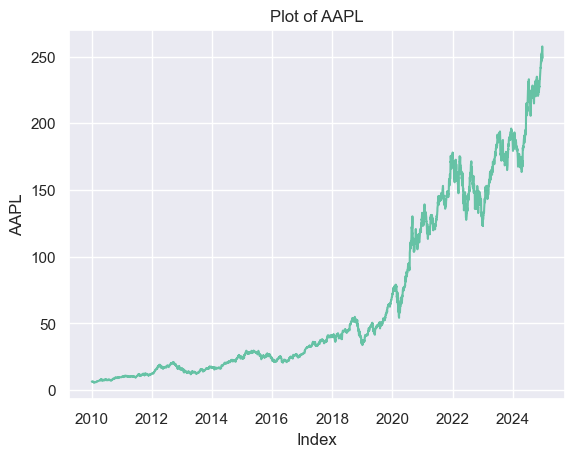

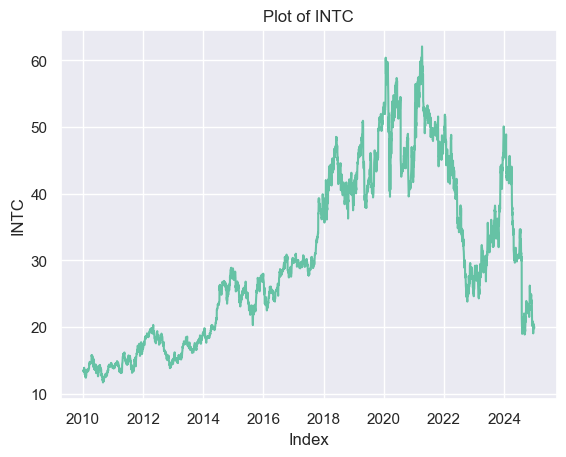

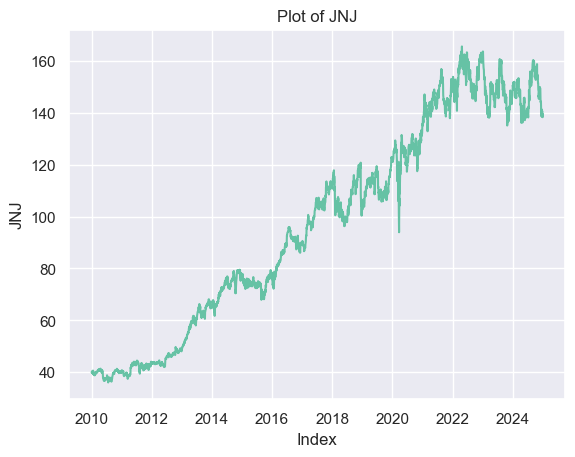

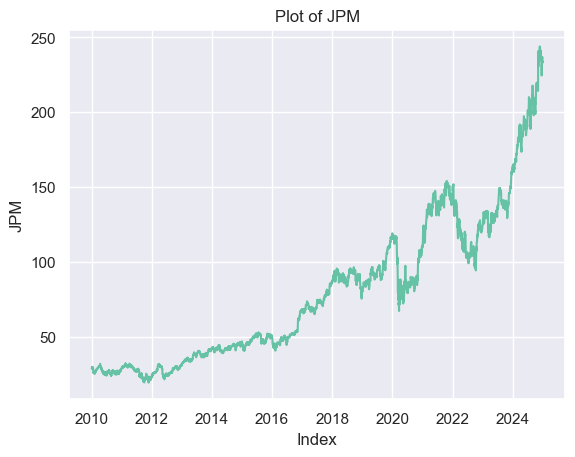

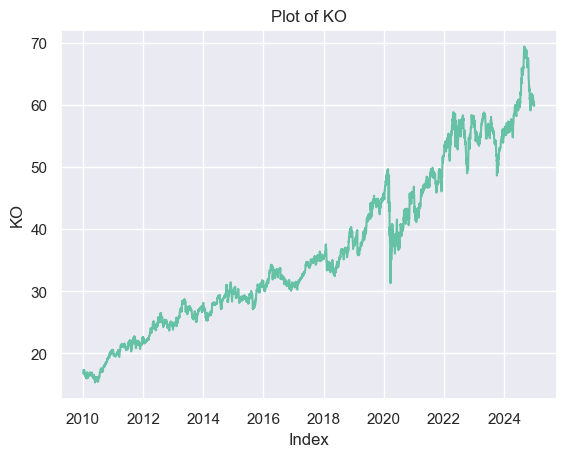

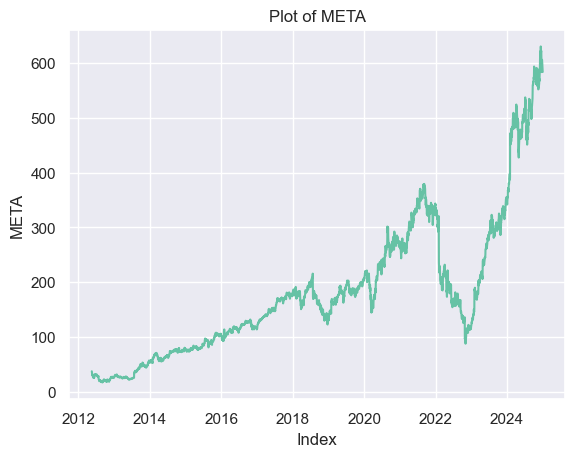

In [8]:
import matplotlib.pyplot as plt

for col in close_prices.columns:
    plt.figure()
    plt.plot(close_prices[col])
    plt.title(f"Plot of {col}")
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.show()

## Mann-Kendall test

In [9]:
! pip install pymannkendall

In [10]:
import pymannkendall as mk

In [11]:
mktest = mk.yue_wang_modification_test(close_prices['AAPL'], lag=4)
print(f"Trend: {mktest[0]}\np-value: {mktest[2]}")

Trend: increasing
p-value: 0.0


In [12]:
rn = red_noise(obs=100, m=0, stdev=0.5, d=1, corr=0.8)
mktest = mk.yue_wang_modification_test(rn, lag=4)
print(f"Trend: {mktest[0]}\np-value: {mktest[2]}")

Trend: no trend
p-value: 0.35355212211178966


## Seasonality

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/vic_electricity.csv",
                 parse_dates=["Time"], index_col="Time", usecols=["Time", "Demand"])
# remove the time zone information
df.index = pd.DatetimeIndex([i.replace(tzinfo=None) for i in df.index])

<Axes: >

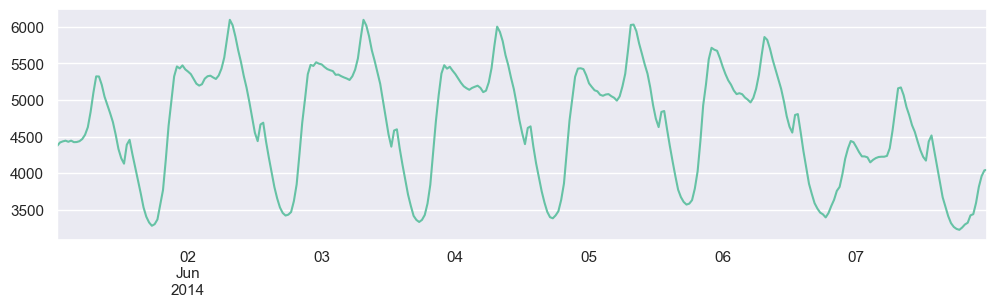

In [ ]:
# examine one week
ts = df[(df.index > datetime.datetime(2014, 6, 1)) & (df.index < datetime.datetime(2014, 6, 8))]["Demand"]
ts.plot(figsize=(12, 3), use_index=True)

<Axes: >

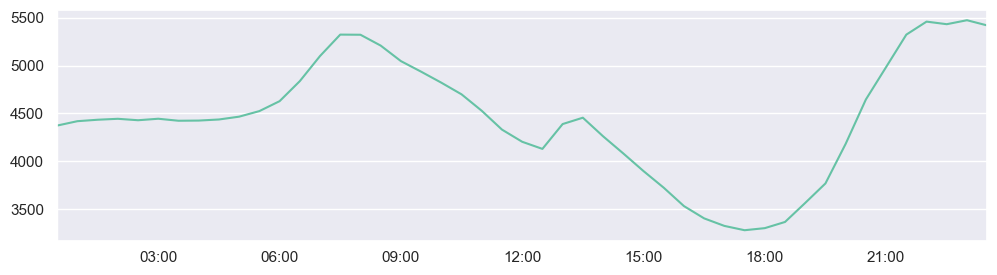

In [ ]:
# examine one day
df[(df.index > datetime.datetime(2014, 6, 1, 0, 0)) & (df.index < datetime.datetime(2014, 6, 1, 23, 59))]["Demand"].plot(figsize=(12, 3), use_index=True)

<Axes: >

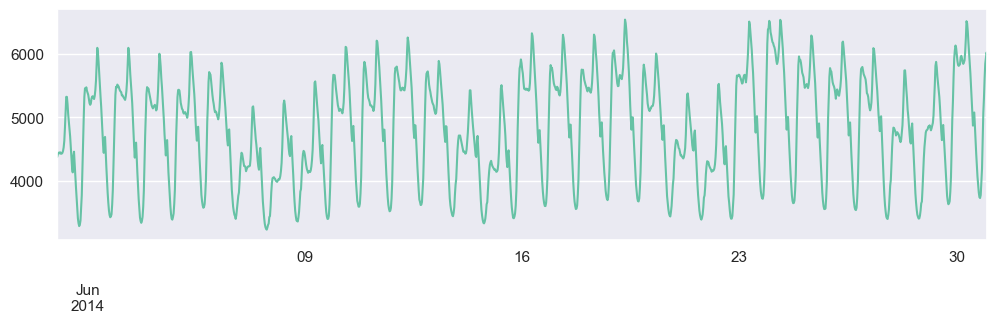

In [ ]:
# examine one month
df[(df.index > datetime.datetime(2014, 6, 1)) & (df.index < datetime.datetime(2014, 7, 1))]["Demand"].plot(figsize=(12, 3), use_index=True)


<Axes: >

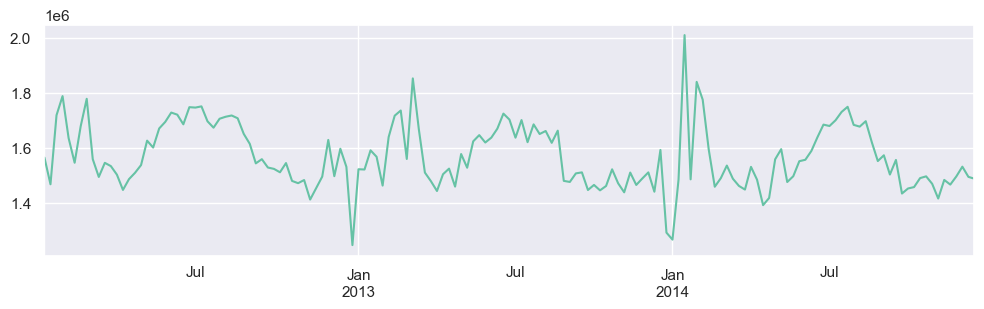

In [ ]:
# examine full dataset aggregated into weekly data
ts = df["Demand"].resample("W").sum()
ts = ts[(ts.index > datetime.datetime(2012, 1, 7)) & (ts.index < datetime.datetime(2014, 12, 24))]
ts.plot(figsize=(12, 3), use_index=True)

### Seasonal plot

In [ ]:
# Extract week number and the name of the day
df['week'] = df.index.isocalendar().week
df['day_of_week'] = df.index.day_name()
df['day_of_week'] = pd.Categorical(df['day_of_week'], 
        ["Monday", "Tuesday", "Wednesday", "Thursday", 
         "Friday", "Saturday", "Sunday"])
df.head()

,Demand,week,day_of_week
2011-12-31 13:00:00,4382.825174,52,Saturday
2011-12-31 13:30:00,4263.365526,52,Saturday
2011-12-31 14:00:00,4048.966046,52,Saturday
2011-12-31 14:30:00,3877.563330,52,Saturday
2011-12-31 15:00:00,4036.229746,52,Saturday


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52608 entries, 2011-12-31 13:00:00 to 2014-12-31 12:30:00
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Demand       52608 non-null  float64 
 1   week         52608 non-null  UInt32  
 2   day_of_week  52608 non-null  category
dtypes: UInt32(1), category(1), float64(1)
memory usage: 1.1 MB


In [ ]:
# Pivot so each week is a row
pivot = df.pivot_table(index='day_of_week', aggfunc="sum",
                       columns='week', values='Demand',
                       observed=False)
pivot.sort_index(inplace=True)
pivot

week,1,2,3,4,5,6,7,8,9,10,...,43,44,45,46,47,48,49,50,51,52
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,827750.653090,674221.193772,749072.010496,752130.495514,716979.086332,697279.752090,691900.541870,757496.127542,752401.564414,711227.203310,...,660927.433008,662375.542756,594331.723836,657118.446978,650593.227514,659188.873666,708692.811834,654406.731422,669632.475110,615773.157504
Tuesday,808787.677756,641758.311000,864197.644888,738485.122714,750291.898172,691453.803688,729361.226498,703227.025360,721055.853030,750889.128880,...,669181.063618,678520.878552,589489.900978,667448.111404,663063.597578,663999.055548,682557.371744,663755.984474,683162.665032,552957.866992
Wednesday,698330.073046,631021.420484,823729.152880,687883.860392,697117.005144,749043.603090,789312.463656,696105.692206,683073.607850,734617.312846,...,679598.369342,672553.472878,654257.482636,675644.985924,663437.518124,715114.219180,664586.513810,706550.477470,691427.498970,539429.807386
Thursday,659933.806636,677148.136066,887293.540318,736490.723214,727768.906274,782612.835158,763217.188128,713260.326942,656698.684714,734101.753202,...,676219.902158,660735.435470,650680.436736,689840.606280,663566.352810,741530.125738,680692.907428,694686.124536,716305.408888,544794.276636
Friday,677977.660828,694032.318662,749969.986550,672030.883892,684611.856556,725088.094870,704843.215648,717127.161450,621263.065318,695078.471382,...,644847.896302,623877.647036,635224.877236,623966.023266,619006.802132,642261.747300,640851.433834,640494.728480,613770.076486,537801.036800
Saturday,575274.045088,564737.470866,597673.017746,608906.042322,653985.646112,680991.157898,643363.420040,671944.670070,567363.793046,630082.716190,...,569228.188340,548251.838914,563572.148248,554654.069766,574675.919448,559207.198114,573836.218168,579287.450620,577628.081486,615947.420320
Sunday,588154.944318,592634.424342,650119.947940,647524.130352,710161.817098,636470.115058,669660.503980,715855.727134,608677.074662,628690.360228,...,592240.926376,579321.882796,580854.863222,580681.433918,594967.469814,634455.874690,590389.140932,594898.385586,661543.000518,773449.949152


<Axes: xlabel='day_of_week'>

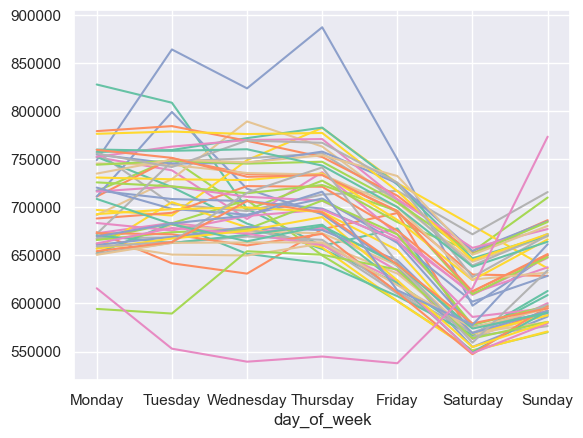

In [133]:
pivot.plot(legend=False)

### Seasonal boxplot

<Axes: title={'center': 'Demand'}, xlabel='day_of_week'>

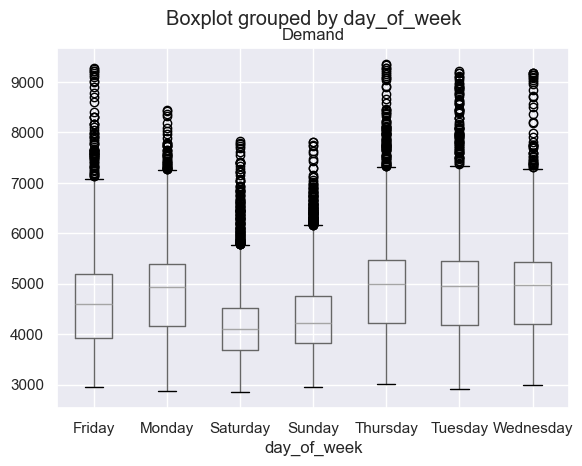

In [21]:
df.boxplot(column='Demand', by='day_of_week')

### Ridge plot

In [22]:
!pip install joypy

In [ ]:
import matplotlib.pyplot as plt
import joypy

# pivot the table so that days of weeks are in rows and
# week numbers are in columns
pivot = df.pivot_table(index='day_of_week', columns='week', values='Demand', aggfunc="sum")

# ensure the smallest y value is 0
pivot = pivot.fillna(pivot.min().min())
pivot = pd.DataFrame(pivot.values - pivot.min().min(), index=pivot.index, columns=pivot.columns)

# ensure the days of week is a categorical variable sortable by custom order
pivot = pivot.reset_index()
pivot['day_of_week'] = pd.Categorical(pivot['day_of_week'], ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

# set day_of_week as the index and sort y index
pivot = pivot.set_index("day_of_week").sort_index()

week,day_of_week,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
0,Friday,997.651572,1109.142251,1497.598278,956.354510,1043.722375,1324.807364,1184.217925,1269.523104,603.800214,...,767.583763,621.957032,700.757241,622.570755,588.131720,749.624394,739.830551,737.353430,551.765569,24.202794
1,Monday,600.674690,971.564995,1491.362333,1512.601813,1268.494804,1131.693872,1094.338246,1549.863146,1514.484236,...,879.247212,889.303530,416.777009,852.795920,807.481896,867.173883,1210.951232,833.964562,939.698893,565.675854
2,Saturday,284.432018,211.261364,439.980439,517.987554,831.040358,1018.578635,757.274900,955.755803,229.499712,...,242.446902,96.777808,203.168846,141.237745,280.278368,172.856692,274.447109,312.302890,300.779493,0.000000
3,Sunday,373.882707,404.990207,804.195232,786.168721,1221.152657,709.404726,939.893538,1260.693699,516.397501,...,402.257583,312.542002,323.187699,321.983329,421.191912,695.416946,389.397961,420.712160,883.521986,317.858523
4,Thursday,872.347029,991.890983,2451.234068,1403.992283,1343.424110,1724.284727,1589.592734,1242.670086,849.880904,...,985.444914,877.913896,808.087516,1080.033137,897.573044,1438.988134,1016.507451,1113.682570,1263.816489,72.766959
5,Tuesday,501.909193,746.128309,2290.845906,1417.842279,1499.833776,1091.235897,1354.481889,1172.994381,1296.805684,...,936.564091,1001.423917,383.153239,924.529701,894.081688,900.577924,1029.455120,898.889930,1033.658545,129.458559
6,Wednesday,397.297331,671.566569,2009.814711,1066.444624,1130.563685,1491.165060,1770.809925,1123.540679,1033.040093,...,1008.906492,959.983600,832.928112,981.452440,896.678359,1255.544338,904.657495,1196.073910,1091.053226,35.513701


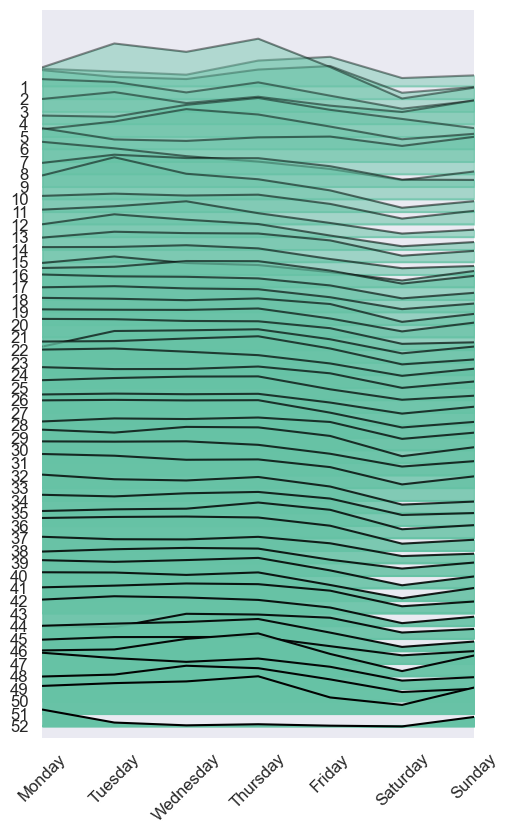

In [106]:
# important to use kind="values" so that actual values, and not KDE, is used
x_range = list(range(7))
fig, axes = joypy.joyplot(pivot, kind="values", x_range=x_range, figsize=(5, 8), fade=True)
_ = axes[-1].set_xticks(ticks=x_range, labels=pivot.index.to_list(), rotation=45)

## Calendar heatmap

In [167]:
!pip install lesley

In [173]:
import lesley

ts = df[(df.index > datetime.datetime(2014, 1, 1)) & (df.index < datetime.datetime(2015, 1, 1))]["Demand"].resample("D").sum()

dates = ts.index
data = ts.values

lesley.cal_heatmap(dates, data)

alt.Chart(...)

In [172]:
ts.values

array([ 82531.745918, 227778.257304, 275490.988882, ..., 188570.258296,
       187212.226846, 104963.021342], shape=(1097,))

## Friedman test

In [ ]:
from scipy.stats import friedmanchisquare

<Axes: xlabel='day_of_week'>

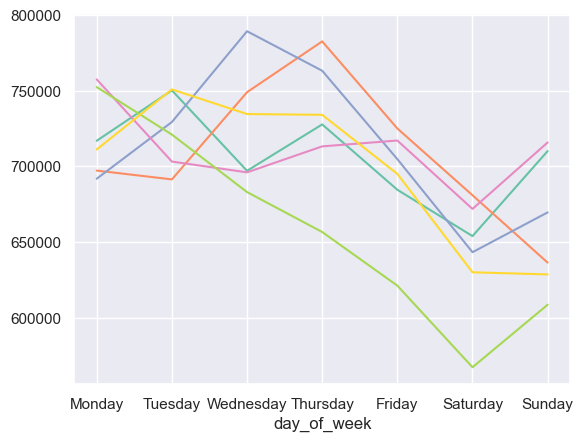

In [ ]:
# plot 5 columns
subpivot = pivot.loc[:, 5:10]
subpivot.plot(legend=False)

In [155]:
subpivot.head()

week,5,6,7,8,9,10
day_of_week,,,,,,
Monday,716979.086332,697279.752090,691900.541870,757496.127542,752401.564414,711227.203310
Tuesday,750291.898172,691453.803688,729361.226498,703227.025360,721055.853030,750889.128880
Wednesday,697117.005144,749043.603090,789312.463656,696105.692206,683073.607850,734617.312846
Thursday,727768.906274,782612.835158,763217.188128,713260.326942,656698.684714,734101.753202
Friday,684611.856556,725088.094870,704843.215648,717127.161450,621263.065318,695078.471382


In [ ]:
pivot.iloc[:,0]

day_of_week
Monday       716979.086332
Tuesday      750291.898172
Wednesday    697117.005144
Thursday     727768.906274
Friday       684611.856556
Saturday     653985.646112
Sunday       710161.817098
Name: 5, dtype: float64

In [ ]:
inputs = [pivot.iloc[:,x] for x in range(5)]
ft_stat, p_val = friedmanchisquare(*inputs)
print(f"The Friedman test statistic: {ft_stat:.3f}, p-value: {p_val:.3f}")

The Friedman test statistic: 5.943, p-value: 0.203


## ACF to detect seasonality

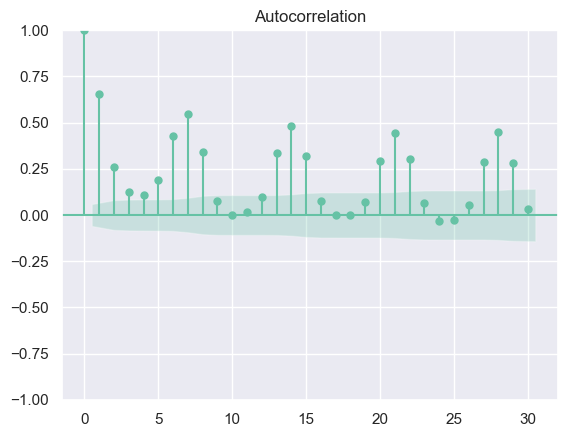

In [163]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

_ = plot_acf(df["Demand"].resample("D").sum(), lags=30)